# Section 1: ติดตั้ง Library

In [9]:
import pandas as pd
import numpy as np
import json

# Section 2: เตรียมข้อมูล


In [97]:
AMPHOE   = "เชียงดาว"
PROVINCE = "เชียงใหม่"
PROVINCE_NUMBER = 6

PARTY_LIST_FILE   = "clean_chiangDao.json"
CONSTITUENCY_FILE = "clean_chiangDao_ss.json"
WIKIPEDIA_COORDS_BY_AMPHOE ={}


## 2.1 Our OCR


### Data Dictionary
#### 1. Summary Tables
* **`df_summary_person`**: สรุปยอดบัตรเลือกตั้ง ส.ส. เขต
* **`df_summary_party`**: สรุปยอดบัตรเลือกตั้ง ปาร์ตี้ลิสต์
* 🏆 **`df_all_summary`**: ตารางรวม (Concat) ของ 2 ตารางด้านบน
  * *คอลัมน์สำคัญ:* `trusted_total` (ยอดบัตรดี), `ballots_used` (คนมาใช้สิทธิ์), `ballots_spoiled` (บัตรเสีย), `ballots_no_vote` (โหวตโน)
  * *Use Case:* หาบัตรเขย่ง, วิเคราะห์สัดส่วนบัตรเสีย/โหวตโน

#### 2. Fact Tables
เก็บข้อมูล **"คะแนนเสียง"** (1 บรรทัด = 1 เบอร์พรรคในแต่ละหน่วย) เน้นประมวลผลไว
* **`df_votes_person`**: คะแนนดิบ ส.ส. เขต (เบอร์ 1-8)
* **`df_votes_party`**: คะแนนดิบ ปาร์ตี้ลิสต์ (เบอร์ 1-57)
* 🏆 **`df_all_votes`**: ตารางรวมคะแนนดิบทั้งหมด
  * *คอลัมน์สำคัญ:* `candidate_party_no` (เบอร์ที่ถูกกา), `votes` (คะแนนที่ได้)
  * *ข้อควรระวัง:* ตารางนี้มีแค่ "เบอร์" ยังไม่มี "ชื่อพรรค"

#### 3. Dimension Tables
Mapping ตัวเลขเบอร์พรรคให้กลายเป็นชื่อพรรคหรือชื่อผู้สมัคร
* **`df_dim_constituency`**: แปลงเบอร์ ส.ส. เขต (ดึงรายชื่อ ส.ส. มาจากไฟล์ JSON)
* **`df_dim_party_list`**: แปลงเบอร์ ปาร์ตี้ลิสต์ (จากลิสต์ 57 พรรค)
* 🏆 **`df_all_dim`**: รวมเล่ม
  * *คอลัมน์สำคัญ:* `candidate_name` (ชื่อ ส.ส.), `party_name` (ชื่อพรรค)

#### 4. Final Report Table
`df_all_votes` Left Join `df_all_dim`
* 🏆 **`df_final_report`**: มีข้อมูลครบจบในตารางเดียว ทั้งคะแนน เบอร์ ชื่อพรรค และชื่อผู้สมัคร
  * *Use Case:* วิเคราะห์ว่าพรรคไหนชนะ, ดูพฤติกรรมกาไขว้พรรค (Split-Ticket Voting), ทำ Dashboard

In [10]:
pathPerson = "clean_chiangDao_ss.json"
pathParty = "clean_chiangDao.json"

with open(pathPerson, encoding="utf-8") as f:
    dataPerson = json.load(f)

with open(pathParty, encoding="utf-8") as f:
    dataParty = json.load(f)

def flatten_election_data(json_data, election_type, amphoe=""):
    summary_rows = []
    vote_rows = []

    for tambon, units in json_data.items():
        for unit_name, unit_data in units.items():
            summary = unit_data.get("ballot_summary", {})
            summary_rows.append({
                "amphoe": amphoe,
                "tambon": tambon,
                "unit": unit_name,
                "type": election_type,
                "trusted_total": unit_data.get("trusted_total"),
                "ballots_used": summary.get("ballots_used"),
                "ballots_valid": summary.get("ballots_valid"),
                "ballots_spoiled": summary.get("ballots_spoiled"),
                "ballots_no_vote": summary.get("ballots_no_vote"),
                "is_manual_edited": unit_data.get("manual_edited", False)
            })
            for candidate_id, votes in unit_data.get("votes", {}).items():
                vote_rows.append({
                    "amphoe": amphoe,
                    "tambon": tambon,
                    "unit": unit_name,
                    "type": election_type,
                    "candidate_party_no": candidate_id,
                    "votes": int(votes)
                })

    return pd.DataFrame(summary_rows), pd.DataFrame(vote_rows)

df_summary_person, df_votes_person = flatten_election_data(dataPerson, "เขต", amphoe="เชียงดาว")
df_summary_party, df_votes_party = flatten_election_data(dataParty, "ปาร์ตี้ลิสต์", amphoe="เชียงดาว")

df_all_summary = pd.concat([df_summary_person, df_summary_party], ignore_index=True)
df_all_votes = pd.concat([df_votes_person, df_votes_party], ignore_index=True)

print(df_all_summary.head())
print('=='*30)
print(df_all_votes.head())

     amphoe           tambon     unit type  trusted_total  ballots_used  \
0  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต            408           447   
1  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 2  เขต            521           586   
2  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 3  เขต            454           500   
3  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 4  เขต            219           234   
4  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 5  เขต            507           574   

   ballots_valid  ballots_spoiled  ballots_no_vote  is_manual_edited  
0            408               18               21              True  
1            521               54               11              True  
2            454               33               13              True  
3            219               15                0              True  
4            507               50               17              True  
     amphoe           tambon     unit type candidate_party_no  votes
0  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต            

In [11]:
PARTY_NAMES = [
    "ไทยทรัพย์ทวี", "เพื่อชาติไทย", "ใหม่", "มิติใหม่", "รวมใจไทย",
    "รวมไทยสร้างชาติ", "พลวัต", "ประชาธิปไตยใหม่", "เพื่อไทย", "ทางเลือกใหม่",
    "เศรษฐกิจ", "เสรีรวมไทย", "รวมพลังประชาชน", "ท้องที่ไทย", "อนาคตไทย",
    "พลังเพื่อไทย", "ไทยชนะ", "พลังสังคมใหม่", "สังคมประชาธิปไตยไทย", "ฟิวชัน",
    "ไทรวมพลัง", "ก้าวอิสระ", "ปวงชนไทย", "วิชชั่นใหม่", "เพื่อชีวิตใหม่",
    "คลองไทย", "ประชาธิปัตย์", "ไทยก้าวหน้า", "ไทยภักดี", "แรงงานสร้างชาติ",
    "ประชากรไทย", "ครูไทยเพื่อประชาชน", "ประชาชาติ", "สร้างอนาคตไทย", "รักชาติ",
    "ไทยพร้อม", "ภูมิใจไทย", "พลังธรรมใหม่", "กรีน", "ไทยธรรม",
    "แผ่นดินธรรม", "กล้าธรรม", "พลังประชารัฐ", "โอกาสใหม่", "เป็นธรรม",
    "ประชาชน", "ประชาไทย", "ไทยสร้างไทย", "ไทยก้าวใหม่", "ประชาอาสาชาติ",
    "พร้อม", "เครือข่ายชาวนาแห่งประเทศไทย", "ไทยพิทักษ์ธรรม", "ความหวังใหม่",
    "ไทยรวมไทย", "เพื่อบ้านเมือง", "พลังไทยรักชาติ"
]

df_dim_party_list = pd.DataFrame({
    "type": "ปาร์ตี้ลิสต์",
    "candidate_party_no": [str(i) for i in range(1, len(PARTY_NAMES) + 1)],
    "party_name": PARTY_NAMES
})

print(df_dim_party_list.head())

           type candidate_party_no    party_name
0  ปาร์ตี้ลิสต์                  1  ไทยทรัพย์ทวี
1  ปาร์ตี้ลิสต์                  2  เพื่อชาติไทย
2  ปาร์ตี้ลิสต์                  3          ใหม่
3  ปาร์ตี้ลิสต์                  4      มิติใหม่
4  ปาร์ตี้ลิสต์                  5      รวมใจไทย


In [12]:
dim_constituency_rows = []

for tambon, units in dataPerson.items():
    for unit_name, unit_data in units.items():
        candidate_info = unit_data.get("candidate_info", {})
        for cand_no, info in candidate_info.items():
            dim_constituency_rows.append({
                "type": "เขต",
                "candidate_party_no": str(cand_no),
                "candidate_name": info["name"],
                "party_name": info["party"]
            })

df_dim_constituency = pd.DataFrame(dim_constituency_rows).drop_duplicates().reset_index(drop=True)
df_all_dim = pd.concat([df_dim_constituency, df_dim_party_list], ignore_index=True)
df_all_votes['candidate_party_no'] = df_all_votes['candidate_party_no'].astype(str)
df_final_report = pd.merge(df_all_votes, df_all_dim,
                           on=['type', 'candidate_party_no'],
                           how='left')

print("\n=== ตารางคะแนนที่พร้อมเอาไปวิเคราะห์ (df_final_report) ===")
print(df_final_report.head(10))


=== ตารางคะแนนที่พร้อมเอาไปวิเคราะห์ (df_final_report) ===
     amphoe           tambon     unit type candidate_party_no  votes  \
0  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  1    101   
1  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  2    192   
2  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  2    192   
3  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  2    192   
4  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  3      2   
5  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  3      2   
6  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  3      2   
7  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  3      2   
8  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  3      2   
9  เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1  เขต                  3      2   

                      candidate_name     party_name  
0         นางสาวสุภานันท์ ปัญญาทิพย์       กล้าธรรม  
1  ว่าที่ ร.ต.หญิง อรพรรณ จันตาเรือง   

## 2.2 Election 66 Results

In [15]:
df_election = pd.read_csv('election_scores_2566.csv')
df_location = pd.read_csv('election_locations_66.csv')

df_cm6_election = df_election[
    (df_election['province'] == PROVINCE) &
    (df_election['province_number'] == PROVINCE_NUMBER)
].copy()
df_cm6_location = df_location[
    (df_location['provincename'] == f"จังหวัด{PROVINCE}") &
    (df_location['divisionnumber'] == PROVINCE_NUMBER)
].copy()

# join district + subdistrict
df_final_cm6 = pd.merge(
    df_cm6_election,
    df_cm6_location[['districtname', 'subdistrictname', 'lat_changable', 'lng_changable']],
    left_on=['district', 'subdistrict'],
    right_on=['districtname', 'subdistrictname'],
    how='left'
)

df_final_cm6 = df_final_cm6.drop(columns=['districtname', 'subdistrictname'])

print("=== ข้อมูลเชียงใหม่ เขต 6 พร้อมพิกัดแผนที่ ===")
print(df_final_cm6)

=== ข้อมูลเชียงใหม่ เขต 6 พร้อมพิกัดแผนที่ ===
          id  index_no document   province  province_number district  \
0     213023   57913.0   สส5/18  เชียงใหม่                6    พร้าว   
1     213023   57913.0   สส5/18  เชียงใหม่                6    พร้าว   
2     213023   57913.0   สส5/18  เชียงใหม่                6    พร้าว   
3     213023   57913.0   สส5/18  เชียงใหม่                6    พร้าว   
4     213023   57913.0   สส5/18  เชียงใหม่                6    พร้าว   
...      ...       ...      ...        ...              ...      ...   
2709  213256       NaN   สส5/17  เชียงใหม่                6      NaN   
2710  213257       NaN   สส5/17  เชียงใหม่                6      NaN   
2711  213258       NaN   สส5/17  เชียงใหม่                6      NaN   
2712  213259       NaN   สส5/17  เชียงใหม่                6      NaN   
2713  213260       NaN   สส5/17  เชียงใหม่                6      NaN   

     subdistrict                registrar  station_number  บช_ก้าวไกล  ...  \
0        ส

In [16]:
df_final_cm6 = df_final_cm6.dropna(axis=1, how='all')

print(df_final_cm6.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2714 entries, 0 to 2713
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2714 non-null   int64  
 1   index_no             2705 non-null   float64
 2   document             2714 non-null   object 
 3   province             2714 non-null   object 
 4   province_number      2714 non-null   int64  
 5   district             2705 non-null   object 
 6   subdistrict          2705 non-null   object 
 7   registrar            2714 non-null   object 
 8   station_number       2705 non-null   float64
 9   บช_ก้าวไกล           2714 non-null   int64  
 10  บช_ชาติพัฒนากล้า     2714 non-null   int64  
 11  บช_ชาติไทยพัฒนา      2714 non-null   int64  
 12  บช_บัตรเสีย          2714 non-null   int64  
 13  บช_ประชาชาติ         2714 non-null   int64  
 14  บช_ประชาธิปัตย์      2714 non-null   int64  
 15  บช_ผู้มาใช้สิทธิ์    2714 non-null   i

In [17]:
df_final_cm6[['province', 'district', 'subdistrict','registrar']]

,province,district,subdistrict,registrar
0,เชียงใหม่,พร้าว,สันทราย,อำเภอพร้าว
1,เชียงใหม่,พร้าว,สันทราย,อำเภอพร้าว
2,เชียงใหม่,พร้าว,สันทราย,อำเภอพร้าว
3,เชียงใหม่,พร้าว,สันทราย,อำเภอพร้าว
4,เชียงใหม่,พร้าว,สันทราย,อำเภอพร้าว
...,...,...,...,...
2709,เชียงใหม่,NaN,NaN,ล่วงหน้านอกเขตเลือกตั้ง
2710,เชียงใหม่,NaN,NaN,ล่วงหน้านอกเขตเลือกตั้ง
2711,เชียงใหม่,NaN,NaN,ล่วงหน้านอกเขตเลือกตั้ง
2712,เชียงใหม่,NaN,NaN,ล่วงหน้านอกเขตเลือกตั้ง


## 2.3 รวม 66&69

In [18]:
print(df_final_report.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8505 entries, 0 to 8504
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   amphoe              8505 non-null   object
 1   tambon              8505 non-null   object
 2   unit                8505 non-null   object
 3   type                8505 non-null   object
 4   candidate_party_no  8505 non-null   object
 5   votes               8505 non-null   int64 
 6   candidate_name      2520 non-null   object
 7   party_name          8505 non-null   object
dtypes: int64(1), object(7)
memory usage: 531.7+ KB
None


In [19]:
print(df_final_cm6.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2714 entries, 0 to 2713
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2714 non-null   int64  
 1   index_no             2705 non-null   float64
 2   document             2714 non-null   object 
 3   province             2714 non-null   object 
 4   province_number      2714 non-null   int64  
 5   district             2705 non-null   object 
 6   subdistrict          2705 non-null   object 
 7   registrar            2714 non-null   object 
 8   station_number       2705 non-null   float64
 9   บช_ก้าวไกล           2714 non-null   int64  
 10  บช_ชาติพัฒนากล้า     2714 non-null   int64  
 11  บช_ชาติไทยพัฒนา      2714 non-null   int64  
 12  บช_บัตรเสีย          2714 non-null   int64  
 13  บช_ประชาชาติ         2714 non-null   int64  
 14  บช_ประชาธิปัตย์      2714 non-null   int64  
 15  บช_ผู้มาใช้สิทธิ์    2714 non-null   i

In [ ]:
df_69_tambons = df_final_report[['amphoe', 'tambon']].drop_duplicates().copy()
df_69_tambons['tambon_clean'] = (
    df_69_tambons['tambon']
    .str.replace('ตำบล', '')
    .str.strip()
)

df_66_tambons = df_final_cm6[
    df_final_cm6['district'] == 'เชียงดาว'
][['district', 'subdistrict']].drop_duplicates().copy()
df_66_tambons = df_66_tambons.dropna(subset=['subdistrict'])
df_66_tambons['subdistrict_clean'] = df_66_tambons['subdistrict'].str.strip()

set_69 = set(df_69_tambons['tambon_clean'])
set_66 = set(df_66_tambons['subdistrict_clean'])

matched = set_69 & set_66
only_in_69 = set_69 - set_66
only_in_66 = set_66 - set_69

print(f" Match ได้: {len(matched)} ตำบล → {sorted(matched)}")
print(f"  มีใน 69 แต่ไม่มีใน 66: {sorted(only_in_69)}")
print(f"  มีใน 66 แต่ไม่มีใน 69: {sorted(only_in_66)}")

df_69_by_tambon = df_final_report[df_final_report['type'] == 'เขต'].copy()
df_69_by_tambon['tambon_key'] = (
    df_69_by_tambon['tambon']
    .str.replace('ตำบล', '')
    .str.strip()
)
df_69_by_tambon = df_69_by_tambon[df_69_by_tambon['tambon_key'].isin(matched)]  # 👈 filter เฉพาะที่ match
df_69_agg = df_69_by_tambon.groupby(['tambon_key', 'party_name'])['votes'].sum().reset_index()
df_69_agg = df_69_agg.rename(columns={'votes': 'votes_69'})

party_cols = [c for c in df_final_cm6.columns if c.startswith('บช_')
              and c not in ['บช_บัตรเสีย', 'บช_ผู้มาใช้สิทธิ์', 'บช_ผู้มีสิทธิ์', 'บช_ไม่เลือกผู้ใด']]

df_66_long = df_final_cm6[
    df_final_cm6['district'] == 'เชียงดาว'
][['subdistrict'] + party_cols].copy()

df_66_long = df_66_long[df_66_long['subdistrict'].isin(matched)]

df_66_long = df_66_long.melt(
    id_vars='subdistrict',
    value_vars=party_cols,
    var_name='party_name',
    value_name='votes_66'
)

df_66_long['party_name'] = df_66_long['party_name'].str.replace('บช_', '')
df_66_long = df_66_long.rename(columns={'subdistrict': 'tambon_key'})
df_66_agg = df_66_long.groupby(['tambon_key', 'party_name'])['votes_66'].sum().reset_index()
df_compare = pd.merge(df_69_agg, df_66_agg, on=['tambon_key', 'party_name'], how='inner')
df_compare['vote_swing'] = df_compare['votes_69'] - df_compare['votes_66']

print(df_compare.sort_values('vote_swing', ascending=False).head(20))

✅ Match ได้: 6 ตำบล → ['ทุ่งข้าวพวง', 'ปิงโค้ง', 'เชียงดาว', 'เมืองคอง', 'เมืองนะ', 'แม่นะ']
⚠️  มีใน 69 แต่ไม่มีใน 66: ['ทต.พระธาตุปู่ก่ำ', 'ทต.เชียงดาว', 'ทต.เมืองงาย']
⚠️  มีใน 66 แต่ไม่มีใน 69: ['เมืองงาย']
     tambon_key       party_name  votes_69  votes_66  vote_swing
7       ปิงโค้ง         เพื่อไทย      8600      1258        7342
19      เมืองนะ         เพื่อไทย      4128      2019        2109
3   ทุ่งข้าวพวง         เพื่อไทย      2796       987        1809
17      เมืองนะ        ภูมิใจไทย       211        48         163
16      เมืองนะ     ประชาธิปัตย์       180        52         128
5       ปิงโค้ง        ภูมิใจไทย       117        37          80
1   ทุ่งข้าวพวง        ภูมิใจไทย        71        28          43
0   ทุ่งข้าวพวง     ประชาธิปัตย์        47        16          31
4       ปิงโค้ง     ประชาธิปัตย์        55        33          22
12     เมืองคอง     ประชาธิปัตย์        56        54           2
13     เมืองคอง        ภูมิใจไทย        27        36          -9
2   ทุ่งข

In [21]:
parties_69 = set(df_69_agg['party_name'])
parties_66 = set(df_66_agg['party_name'])
print("match:", parties_69 & parties_66)
print("only 69:", parties_69 - parties_66)
print("only 66:", parties_66 - parties_69)

match: {'เพื่อไทย', 'ประชาธิปัตย์', 'ภูมิใจไทย', 'รวมไทยสร้างชาติ'}
only 69: {'วิชช์ชื่นใหม่', 'ประชาชน', 'วิชช์ชั่นใหม่', 'วิชช์ซันใหม่', 'วิชช์ใหม่', 'กล้าธรรม', 'เศรษฐกิจ', 'วิชชั่นใหม่', 'วิชช์นิ่มใหม่', 'วิชช์นใหม่', 'วิชชันใหม่', 'วิชช่นใหม่'}
only 66: {'ประชาชาติ', 'ชาติพัฒนากล้า', 'ชาติไทยพัฒนา', 'ก้าวไกล', 'พลังประชารัฐ', 'เสรีรวมไทย', 'ไทยสร้างไทย'}


In [ ]:
df_69_tambons = df_final_report[['amphoe', 'tambon']].drop_duplicates().copy()
df_69_tambons['tambon_clean'] = (
    df_69_tambons['tambon']
    .str.replace('ตำบล', '')
    .str.strip()
)

df_66_tambons = df_final_cm6[
    df_final_cm6['district'] == 'เชียงดาว'
][['district', 'subdistrict']].drop_duplicates().copy()
df_66_tambons = df_66_tambons.dropna(subset=['subdistrict'])
df_66_tambons['subdistrict_clean'] = df_66_tambons['subdistrict'].str.strip()

set_69 = set(df_69_tambons['tambon_clean'])
set_66 = set(df_66_tambons['subdistrict_clean'])

matched = set_69 & set_66
only_in_69 = set_69 - set_66
only_in_66 = set_66 - set_69

print(f" Match ได้: {len(matched)} ตำบล → {sorted(matched)}")
print(f"  มีใน 69 แต่ไม่มีใน 66: {sorted(only_in_69)}")
print(f" มีใน 66 แต่ไม่มีใน 69: {sorted(only_in_66)}")

party_name_fix = {
    'วิชช์ชื่นใหม่':  'วิชชั่นใหม่',
    'วิชช์นใหม่':    'วิชชั่นใหม่',
    'วิชช์ชั่นใหม่':  'วิชชั่นใหม่',
    'วิชชันใหม่':    'วิชชั่นใหม่',
    'วิชช่นใหม่':    'วิชชั่นใหม่',
    'วิชช์นิ่มใหม่':  'วิชชั่นใหม่',
    'วิชช์ซันใหม่':   'วิชชั่นใหม่',
    'วิชช์ใหม่':     'วิชชั่นใหม่',
}

df_69_by_tambon = df_final_report[df_final_report['type'] == 'เขต'].copy()
df_69_by_tambon['tambon_key'] = (
    df_69_by_tambon['tambon']
    .str.replace('ตำบล', '')
    .str.strip()
)
df_69_by_tambon = df_69_by_tambon[df_69_by_tambon['tambon_key'].isin(matched)]
df_69_by_tambon['party_name'] = df_69_by_tambon['party_name'].replace(party_name_fix)  # 👈 normalize OCR

df_69_agg = df_69_by_tambon.groupby(['tambon_key', 'party_name'])['votes'].sum().reset_index()
df_69_agg = df_69_agg.rename(columns={'votes': 'votes_69'})

party_cols = [c for c in df_final_cm6.columns if c.startswith('บช_')
              and c not in ['บช_บัตรเสีย', 'บช_ผู้มาใช้สิทธิ์', 'บช_ผู้มีสิทธิ์', 'บช_ไม่เลือกผู้ใด']]

df_66_long = df_final_cm6[
    df_final_cm6['district'] == 'เชียงดาว'
][['subdistrict'] + party_cols].copy()

df_66_long = df_66_long[df_66_long['subdistrict'].isin(matched)]

df_66_long = df_66_long.melt(
    id_vars='subdistrict',
    value_vars=party_cols,
    var_name='party_name',
    value_name='votes_66'
)

df_66_long['party_name'] = df_66_long['party_name'].str.replace('บช_', '')
df_66_long = df_66_long.rename(columns={'subdistrict': 'tambon_key'})

df_66_agg = df_66_long.groupby(['tambon_key', 'party_name'])['votes_66'].sum().reset_index()

df_compare = pd.merge(df_69_agg, df_66_agg, on=['tambon_key', 'party_name'], how='inner')
df_compare['vote_swing'] = df_compare['votes_69'] - df_compare['votes_66']

print(df_compare.sort_values('vote_swing', ascending=False).head(20))

✅ Match ได้: 6 ตำบล → ['ทุ่งข้าวพวง', 'ปิงโค้ง', 'เชียงดาว', 'เมืองคอง', 'เมืองนะ', 'แม่นะ']
⚠️  มีใน 69 แต่ไม่มีใน 66: ['ทต.พระธาตุปู่ก่ำ', 'ทต.เชียงดาว', 'ทต.เมืองงาย']
⚠️  มีใน 66 แต่ไม่มีใน 69: ['เมืองงาย']
     tambon_key       party_name  votes_69  votes_66  vote_swing
7       ปิงโค้ง         เพื่อไทย      8600      1258        7342
19      เมืองนะ         เพื่อไทย      4128      2019        2109
3   ทุ่งข้าวพวง         เพื่อไทย      2796       987        1809
17      เมืองนะ        ภูมิใจไทย       211        48         163
16      เมืองนะ     ประชาธิปัตย์       180        52         128
5       ปิงโค้ง        ภูมิใจไทย       117        37          80
1   ทุ่งข้าวพวง        ภูมิใจไทย        71        28          43
0   ทุ่งข้าวพวง     ประชาธิปัตย์        47        16          31
4       ปิงโค้ง     ประชาธิปัตย์        55        33          22
12     เมืองคอง     ประชาธิปัตย์        56        54           2
13     เมืองคอง        ภูมิใจไทย        27        36          -9
2   ทุ่งข

# Section 3: Hypothiesis

## ค้นหา & กรองข้อมูล (Filtering)


In [ ]:
# 1. ดูคะแนนของพรรคใดพรรคหนึ่งโดยเฉพาะ
df_prachachon = df_final_report[df_final_report['party_name'] == 'ประชาชน']
print("=== คะแนนพรรคประชาชน ===")
print(df_prachachon.to_string(index=False))

# 2. ดูเฉพาะคะแนนของ "ส.ส. เขต" ใน "ตำบลทุ่งข้าวพวง"
df_thung_khao = df_final_report[(df_final_report['type'] == 'เขต') & (df_final_report['tambon'] == 'ตำบลทุ่งข้าวพวง')]
print("\n=== ส.ส. เขต ตำบลทุ่งข้าวพวง ===")
print(df_thung_khao.to_string(index=False))

# 3. ดูหน่วยที่คะแนนพรรคใดพรรคหนึ่ง ชนะขาด
df_landslide = df_final_report[df_final_report['votes'] > 200]
print("\n=== หน่วยที่ได้คะแนนเกิน 200 โหวต ===")
print(df_landslide.to_string(index=False))

=== คะแนนพรรคประชาชน ===
  amphoe           tambon     unit         type candidate_party_no  votes                    candidate_name party_name
เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1          เขต                  2    192 ว่าที่ ร.ต.หญิง อรพรรณ จันตาเรือง    ประชาชน
เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1          เขต                  2    192   วาที ร.ต.หญิง อรพรรณ จันตาเรือง    ประชาชน
เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 1          เขต                  2    192  วาที่ ร.ต.หญิง อรพรรณ จันตาเรือง    ประชาชน
เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 2          เขต                  2    151 ว่าที่ ร.ต.หญิง อรพรรณ จันตาเรือง    ประชาชน
เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 2          เขต                  2    151   วาที ร.ต.หญิง อรพรรณ จันตาเรือง    ประชาชน
เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 2          เขต                  2    151  วาที่ ร.ต.หญิง อรพรรณ จันตาเรือง    ประชาชน
เชียงดาว  ตำบลทุ่งข้าวพวง  หน่วย 3          เขต                  2    163 ว่าที่ ร.ต.หญิง อรพรรณ จันตาเรือง    ประชาชน
เชียงดาว  ตำบลทุ่งข้าวพ

## 3.2. จัดอันดับ 

In [ ]:
# 1. รวมคะแนนทั้งเขตเลือกตั้ง ว่าพรรคไหนได้คะแนนรวมสูงสุด (เรียงจากมากไปน้อย)
top_parties = df_final_report[df_final_report['type'] == 'เขต'].groupby('party_name')['votes'].sum().sort_values(ascending=False)
print("=== คะแนนรวมทุกพรรค (ส.ส. เขต) ===")
print(top_parties.to_string())

# 2. หา "แชมป์ประจำตำบล" (พรรคที่ได้คะแนนอันดับ 1 ในแต่ละตำบล)
tambon_champ = df_final_report[df_final_report['type'] == 'ปาร์ตี้ลิสต์'].groupby(['tambon', 'party_name'])['votes'].sum().reset_index()
best_in_tambon = tambon_champ.loc[tambon_champ.groupby('tambon')['votes'].idxmax()]
print("\n=== แชมป์ประจำตำบล (ปาร์ตี้ลิสต์) ===")
print(best_in_tambon.to_string(index=False))

=== คะแนนรวมทุกพรรค (ส.ส. เขต) ===
party_name
ประชาชน            33051
เพื่อไทย           33000
กล้าธรรม           10751
ภูมิใจไทย           1021
เศรษฐกิจ             864
ประชาธิปัตย์         653
วิชชั่นใหม่          262
วิชช์นใหม่           262
รวมไทยสร้างชาติ      258
วิชชันใหม่           131
วิชช่นใหม่           131
วิชช์ชั่นใหม่        131
วิชช์นิ่มใหม่        131
วิชช์ซันใหม่         131
วิชช์ชื่นใหม่        131
วิชช์ใหม่            131

=== แชมป์ประจำตำบล (ปาร์ตี้ลิสต์) ===
          tambon party_name  votes
 ตำบลทุ่งข้าวพวง    ประชาชน   1199
     ตำบลปิงโค้ง   เพื่อไทย   1938
    ตำบลเชียงดาว    ประชาชน   1904
    ตำบลเมืองคอง    ประชาชน    579
     ตำบลเมืองนะ    ประชาชน   2953
       ตำบลแม่นะ    ประชาชน   1508
ทต.พระธาตุปู่ก่ำ    ประชาชน    397
     ทต.เชียงดาว    ประชาชน    786
     ทต.เมืองงาย    ประชาชน    674


## 3.3. จับผิดความโปร่งใส (Anomaly Detection)

In [ ]:
# 1. ตรวจสอบ "บัตรเขย่ง" (บัตรที่ใช้ไป ไม่เท่ากับ บัตรดี + บัตรเสีย + โหวตโน)
df_all_summary['check_sum'] = df_all_summary['ballots_valid'] + df_all_summary['ballots_spoiled'] + df_all_summary['ballots_no_vote']
df_ghost_ballots = df_all_summary[df_all_summary['ballots_used'] != df_all_summary['check_sum']]
print(f"=== บัตรเขย่ง: พบ {len(df_ghost_ballots)} หน่วย ===")
print(df_ghost_ballots[['amphoe','tambon','unit','type','ballots_used','check_sum']].to_string(index=False))

# 2. หา Top 5 หน่วยที่มี "บัตรเสีย" สูงที่สุด
top_spoiled = df_all_summary.nlargest(5, 'ballots_spoiled')
print("\n=== Top 5 หน่วยบัตรเสียสูงสุด ===")
print(top_spoiled[['amphoe','tambon','unit','type','ballots_spoiled']].to_string(index=False))

# 3. คำนวณ "เปอร์เซ็นต์บัตรเสีย" (Spoiled Rate) เพื่อให้เทียบกันแฟร์ๆ
df_all_summary['spoiled_rate_percent'] = (df_all_summary['ballots_spoiled'] / df_all_summary['ballots_used']) * 100
# ดูหน่วยที่มีบัตรเสียเกิน 10%
high_spoiled_rate = df_all_summary[df_all_summary['spoiled_rate_percent'] > 10]
print(f"\n=== หน่วยที่บัตรเสียเกิน 10%: พบ {len(high_spoiled_rate)} หน่วย ===")
print(high_spoiled_rate[['amphoe','tambon','unit','type','ballots_spoiled','ballots_used','spoiled_rate_percent']].to_string(index=False))

=== บัตรเขย่ง: พบ 0 หน่วย ===
Empty DataFrame
Columns: [amphoe, tambon, unit, type, ballots_used, check_sum]
Index: []

=== Top 5 หน่วยบัตรเสียสูงสุด ===
  amphoe      tambon     unit         type  ballots_spoiled
เชียงดาว ตำบลเมืองนะ หน่วย 20          เขต               95
เชียงดาว ตำบลเมืองนะ หน่วย 16          เขต               78
เชียงดาว   ตำบลแม่นะ  หน่วย 4          เขต               66
เชียงดาว ตำบลเมืองนะ หน่วย 21          เขต               64
เชียงดาว ตำบลเมืองนะ หน่วย 17 ปาร์ตี้ลิสต์               64

=== หน่วยที่บัตรเสียเกิน 10%: พบ 27 หน่วย ===
  amphoe          tambon     unit         type  ballots_spoiled  ballots_used  spoiled_rate_percent
เชียงดาว ตำบลทุ่งข้าวพวง  หน่วย 7          เขต               44           347             12.680115
เชียงดาว     ตำบลปิงโค้ง หน่วย 15          เขต               37           288             12.847222
เชียงดาว     ตำบลปิงโค้ง หน่วย 17          เขต               18           138             13.043478
เชียงดาว     ตำบลปิงโค้ง  หน่วย 3      

## 3.4. Split-Ticket เช่น "คนในหน่วยนี้ เลือก ส.ส. เขต พรรค A แล้วเลือก ปาร์ตี้ลิสต์ พรรค A เหมือนกันไหม?"

In [ ]:
df_pivot = df_final_report.pivot_table(
    index=['tambon', 'unit', 'party_name'],
    columns='type',
    values='votes',
    aggfunc='sum'
).reset_index()

df_pivot = df_pivot.fillna(0)
df_pivot['split_vote_diff'] = df_pivot['ปาร์ตี้ลิสต์'] - df_pivot['เขต']

print("=== Pivot: คะแนนเขต vs ปาร์ตี้ลิสต์ รายหน่วย ===")
print(df_pivot.to_string(index=False))

print("\n=== Top 10 หน่วยที่ Split-Ticket สูงสุด (เทให้ปาร์ตี้ลิสต์มากกว่าเขต) ===")
print(df_pivot.sort_values('split_vote_diff', ascending=False).head(10).to_string(index=False))

Streaming output truncated to the last 5000 lines.
    ตำบลเชียงดาว  หน่วย 1                พลังธรรมใหม่           4.0   0.0              4.0
    ตำบลเชียงดาว  หน่วย 1                พลังประชารัฐ           3.0   0.0              3.0
    ตำบลเชียงดาว  หน่วย 1               พลังสังคมใหม่           0.0   0.0              0.0
    ตำบลเชียงดาว  หน่วย 1                พลังเพื่อไทย           2.0   0.0              2.0
    ตำบลเชียงดาว  หน่วย 1              พลังไทยรักชาติ           0.0   0.0              0.0
    ตำบลเชียงดาว  หน่วย 1                      ฟิวชัน           0.0   0.0              0.0
    ตำบลเชียงดาว  หน่วย 1                   ภูมิใจไทย          53.0  18.0             35.0
    ตำบลเชียงดาว  หน่วย 1                    มิติใหม่           1.0   0.0              1.0
    ตำบลเชียงดาว  หน่วย 1              รวมพลังประชาชน           1.0   0.0              1.0
    ตำบลเชียงดาว  หน่วย 1                    รวมใจไทย           6.0   0.0              6.0
    ตำบลเชียงดาว  หน่วย 1             ร

## 3.5. พรรคไหน swing ขึ้น/ลงกี่% ในแต่ละตำบล


In [ ]:
# คำนวณ vote share % ของแต่ละพรรคในแต่ละตำบล
df_69_share = df_compare.copy()
df_69_share['total_69'] = df_69_share.groupby('tambon_key')['votes_69'].transform('sum')
df_69_share['share_69'] = df_69_share['votes_69'] / df_69_share['total_69'] * 100

df_69_share['total_66'] = df_69_share.groupby('tambon_key')['votes_66'].transform('sum')
df_69_share['share_66'] = df_69_share['votes_66'] / df_69_share['total_66'] * 100

df_69_share['share_swing'] = df_69_share['share_69'] - df_69_share['share_66']

# ตำบลไหนเปลี่ยนใจมากสุด (รวมทุกพรรค เอา abs swing สูงสุด)
tambon_change = df_69_share.groupby('tambon_key')['share_swing'].apply(
    lambda x: x.abs().max()
).sort_values(ascending=False).reset_index()
tambon_change.columns = ['tambon_key', 'max_abs_swing']

print("=== ตำบลที่เปลี่ยนใจมากสุด ===")
print(tambon_change)

print("\n=== พรรคที่ swing ขึ้นมากสุด (ทุกตำบลรวม) ===")
print(df_69_share.groupby('party_name')['share_swing'].mean().sort_values(ascending=False))

=== ตำบลที่เปลี่ยนใจมากสุด ===
    tambon_key  max_abs_swing
0      ปิงโค้ง      25.281348
1      เมืองนะ      24.130286
2  ทุ่งข้าวพวง      19.990101
3     เชียงดาว      16.655054
4        แม่นะ      16.490258
5     เมืองคอง       8.747583

=== พรรคที่ swing ขึ้นมากสุด (ทุกตำบลรวม) ===
party_name
เพื่อไทย           16.860790
ภูมิใจไทย           0.956161
ประชาธิปัตย์        0.386181
รวมไทยสร้างชาติ   -18.203132
Name: share_swing, dtype: float64


## 3.6. Geo Analysis 


In [ ]:
import folium
from folium.plugins import MarkerCluster

df_geo = df_final_cm6[
    df_final_cm6['district'] == 'เชียงดาว'
][['subdistrict', 'lat_changable', 'lng_changable']].dropna().drop_duplicates('subdistrict')

# หาพรรคชนะในแต่ละตำบล ปี 69
winner_69 = df_compare.loc[
    df_compare.groupby('tambon_key')['votes_69'].idxmax()
][['tambon_key', 'party_name', 'votes_69']].rename(columns={'party_name': 'winner_69'})

# หาพรรคชนะในแต่ละตำบล ปี 66
winner_66 = df_compare.loc[
    df_compare.groupby('tambon_key')['votes_66'].idxmax()
][['tambon_key', 'party_name', 'votes_66']].rename(columns={'party_name': 'winner_66'})

df_map = df_geo.merge(winner_69, left_on='subdistrict', right_on='tambon_key', how='inner')
df_map = df_map.merge(winner_66[['tambon_key', 'winner_66']], on='tambon_key', how='left')
df_map['flipped'] = df_map['winner_69'] != df_map['winner_66']

# สร้างแผนที่
m = folium.Map(location=[19.37, 98.97], zoom_start=10)

party_colors = {
    'ประชาชน':      'orange',
    'ก้าวไกล':      'orange',
    'เพื่อไทย':     'red',
    'ภูมิใจไทย':    'blue',
    'รวมไทยสร้างชาติ': 'lightblue',
    'ประชาธิปัตย์': 'darkblue',
}

for _, row in df_map.iterrows():
    color = party_colors.get(row['winner_69'], 'gray')
    flip_icon = '🔄 ' if row['flipped'] else ''
    folium.CircleMarker(
        location=[row['lat_changable'], row['lng_changable']],
        radius=12,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"{flip_icon}<b>{row['subdistrict']}</b><br>"
            f"66: {row['winner_66']}<br>"
            f"69: {row['winner_69']}<br>"
            f"votes_69: {int(row['votes_69'])}",
            max_width=200
        ),
        tooltip=f"{row['subdistrict']} → {row['winner_69']}"
    ).add_to(m)

m.save('election_map.html')
print("บันทึกแผนที่แล้วที่ election_map.html")
m  # แสดงใน notebook

บันทึกแผนที่แล้วที่ election_map.html


In [78]:
import pandas as pd

csv_geo = (df_final_cm6[df_final_cm6["district"] == AMPHOE]
           .groupby("subdistrict")[["lat_changable", "lng_changable"]]
           .mean(numeric_only=True)
           .dropna()
           .reset_index()
           .rename(columns={"subdistrict": "tambon_clean",
                            "lat_changable": "lat", "lng_changable": "lng"}))
csv_geo["source"] = "2566 polling stations (mean)"

WIKIPEDIA_COORDS = {
    "เมืองนะ":       (19.5932, 98.9618),
    "เมืองงาย":      (19.4448, 98.9662),
    "ทุ่งข้าวพวง":   (19.5342, 98.9621),
    "ปิงโค้ง":       (19.4592, 98.9943),
    "พระธาตุปู่ก่ำ":  (19.4500, 98.9900),
}

needed = set(df_unit_cluster["tambon_clean"].unique())
need_wiki = needed - set(csv_geo["tambon_clean"])

wiki_records = [
    {"tambon_clean": t, "lat": lat, "lng": lng, "source": "Wikipedia/Wikidata"}
    for t, (lat, lng) in WIKIPEDIA_COORDS.items() if t in need_wiki
]

geo = pd.concat([csv_geo, pd.DataFrame(wiki_records)], ignore_index=True)
geo = geo[geo["tambon_clean"].isin(needed)].reset_index(drop=True)

print(f"Coverage: {len(geo)}/{len(needed)} ตำบล\n")
print(geo.to_string(index=False))
print(f"\nSources: {geo['source'].value_counts().to_dict()}")

Coverage: 8/8 ตำบล

 tambon_clean       lat       lng                       source
     เชียงดาว 19.377579 98.965117 2566 polling stations (mean)
     เมืองคอง 19.395688 98.718068 2566 polling stations (mean)
        แม่นะ 19.415717 98.940156 2566 polling stations (mean)
      เมืองนะ 19.593200 98.961800           Wikipedia/Wikidata
     เมืองงาย 19.444800 98.966200           Wikipedia/Wikidata
  ทุ่งข้าวพวง 19.534200 98.962100           Wikipedia/Wikidata
      ปิงโค้ง 19.459200 98.994300           Wikipedia/Wikidata
พระธาตุปู่ก่ำ 19.450000 98.990000           Wikipedia/Wikidata

Sources: {'Wikipedia/Wikidata': 5, '2566 polling stations (mean)': 3}


## 3.7. Voter Turnout เปรียบเทียบ 66 vs 69


In [ ]:
df_turnout_69 = df_all_summary[df_all_summary['type'] == 'ปาร์ตี้ลิสต์'].copy()
df_turnout_69['tambon_key'] = df_turnout_69['tambon'].str.replace('ตำบล', '').str.strip()
df_turnout_69 = df_turnout_69[df_turnout_69['tambon_key'].isin(matched)]

df_turnout_69_agg = df_turnout_69.groupby('tambon_key').agg(
    eligible_69=('trusted_total', 'sum'),
    used_69=('ballots_used', 'sum')
).reset_index()
df_turnout_69_agg['turnout_rate_69'] = df_turnout_69_agg['used_69'] / df_turnout_69_agg['eligible_69'] * 100

# Turnout 66 จาก df_final_cm6
df_turnout_66 = df_final_cm6[
    df_final_cm6['district'] == 'เชียงดาว'
][['subdistrict', 'บช_ผู้มีสิทธิ์', 'บช_ผู้มาใช้สิทธิ์']].copy()
df_turnout_66 = df_turnout_66[df_turnout_66['subdistrict'].isin(matched)].dropna()

df_turnout_66_agg = df_turnout_66.groupby('subdistrict').agg(
    eligible_66=('บช_ผู้มีสิทธิ์', 'sum'),
    used_66=('บช_ผู้มาใช้สิทธิ์', 'sum')
).reset_index().rename(columns={'subdistrict': 'tambon_key'})
df_turnout_66_agg['turnout_rate_66'] = df_turnout_66_agg['used_66'] / df_turnout_66_agg['eligible_66'] * 100

# Merge
df_turnout = pd.merge(df_turnout_69_agg, df_turnout_66_agg, on='tambon_key')
df_turnout['turnout_delta'] = df_turnout['turnout_rate_69'] - df_turnout['turnout_rate_66']

print("=== Voter Turnout 66 vs 69 ===")
print(df_turnout[['tambon_key', 'turnout_rate_66', 'turnout_rate_69', 'turnout_delta']]
      .sort_values('turnout_delta', ascending=False).to_string(index=False))

=== Voter Turnout 66 vs 69 ===
 tambon_key  turnout_rate_66  turnout_rate_69  turnout_delta
    เมืองนะ        59.940326       110.357056      50.416730
   เชียงดาว        73.040119       112.752065      39.711945
    ปิงโค้ง        70.901001       109.535804      38.634803
   เมืองคอง        70.524749       109.113765      38.589016
ทุ่งข้าวพวง        73.449288       109.280365      35.831077
      แม่นะ        76.270486       111.661683      35.391197


## 3.8. Swing Voter


In [ ]:
winner_compare = winner_69.merge(winner_66[['tambon_key', 'winner_66']], on='tambon_key')
winner_compare['flipped'] = winner_compare['winner_69'] != winner_compare['winner_66']

print("=== ตำบลที่แชมป์เปลี่ยน (Flipped) ===")
flipped = winner_compare[winner_compare['flipped']]
if flipped.empty:
    print("ไม่มีตำบลที่เปลี่ยนแชมป์")
else:
    print(flipped[['tambon_key', 'winner_66', 'winner_69']].to_string(index=False))

print("\n=== ตำบลที่แชมป์ยังครองได้ ===")
print(winner_compare[~winner_compare['flipped']][['tambon_key', 'winner_69']].to_string(index=False))

=== ตำบลที่แชมป์เปลี่ยน (Flipped) ===
ไม่มีตำบลที่เปลี่ยนแชมป์

=== ตำบลที่แชมป์ยังครองได้ ===
 tambon_key winner_69
ทุ่งข้าวพวง  เพื่อไทย
    ปิงโค้ง  เพื่อไทย
   เชียงดาว  เพื่อไทย
   เมืองคอง  เพื่อไทย
    เมืองนะ  เพื่อไทย
      แม่นะ  เพื่อไทย


## Section 4: Modeling Pipeline

Four analyses on the validated polling-unit data:
-  Vote concentration (ENP, HHI, top-share, margin) — descriptive baseline
-  Compositional clustering of units (PCA + KMeans on top-10 party shares)
-  Anomaly detection (Isolation Forest on per-unit feature vector)
-  Split-ticket regression (OLS + XGBoost + SHAP)

Plus geographic visualization mapping clusters back to ตำบล centroids.

### 4.1 Vote Concentration

**Effective Number of Parties (Laakso-Taagepera)**: ENP = 1 / Σ(sᵢ²) where sᵢ is party i's vote share at a unit. With 57 parties on the ballot, low ENP means voters concentrate on a few parties; high ENP means fragmentation. Reported alongside HHI, top-party share, and victory margin.

In [79]:
import numpy as np
import pandas as pd

def concentration_metrics(group):
    v = group["votes"].values.astype(float)
    total = v.sum()
    if total == 0:
        return pd.Series({"ENP": np.nan, "HHI": np.nan, "top_share": np.nan, "margin": np.nan})
    s = v[v > 0] / total
    s_sorted = np.sort(s)[::-1]
    enp = 1.0 / (s ** 2).sum()
    hhi = (s ** 2).sum()
    top = s_sorted[0]
    margin = s_sorted[0] - s_sorted[1] if len(s_sorted) >= 2 else s_sorted[0]
    return pd.Series({"ENP": enp, "HHI": hhi, "top_share": top, "margin": margin})

df_plist_v = df_final_report[df_final_report["type"] == "ปาร์ตี้ลิสต์"]
df_khet_v  = df_final_report[df_final_report["type"] == "เขต"]

conc_plist = (df_plist_v.groupby(["tambon", "unit"])
              .apply(concentration_metrics).add_suffix("_plist").reset_index())
conc_khet  = (df_khet_v.groupby(["tambon", "unit"])
              .apply(concentration_metrics).add_suffix("_khet").reset_index())
df_conc = conc_plist.merge(conc_khet, on=["tambon", "unit"], how="outer")

print("=== Concentration metrics per unit (head) ===")
print(df_conc.head().to_string(index=False))

print("\n=== Aggregate over the อำเภอ ===")
print(f"Median ENP party-list (out of 57 parties):     {df_conc['ENP_plist'].median():.2f}")
print(f"Median ENP constituency (out of 8 candidates): {df_conc['ENP_khet'].median():.2f}")
print(f"Median top-party share (party-list):           {df_conc['top_share_plist'].median():.1%}")
print(f"Median victory margin (party-list):            {df_conc['margin_plist'].median():.1%}")

print("\n=== Tambon-level concentration ===")
tambon_conc = (df_conc.groupby("tambon")[["ENP_plist", "ENP_khet", "top_share_plist", "margin_plist"]]
               .mean().round(3).sort_values("ENP_plist"))
print(tambon_conc.to_string())

=== Concentration metrics per unit (head) ===
         tambon    unit  ENP_plist  HHI_plist  top_share_plist  margin_plist  ENP_khet  HHI_khet  top_share_khet  margin_khet
ตำบลทุ่งข้าวพวง หน่วย 1   3.508133   0.285052         0.471464      0.243176  7.679946  0.130209        0.177285     0.000000
ตำบลทุ่งข้าวพวง หน่วย 2   4.166123   0.240031         0.441989      0.259669  8.938758  0.111872        0.152922     0.032026
ตำบลทุ่งข้าวพวง หน่วย 3   3.849658   0.259763         0.383621      0.064655  8.467087  0.118104        0.129468     0.000000
ตำบลทุ่งข้าวพวง หน่วย 4   3.152085   0.317250         0.428571      0.069124  8.101586  0.123433        0.147799     0.000000
ตำบลทุ่งข้าวพวง หน่วย 5   5.672637   0.176285         0.353965      0.164410  7.081205  0.141219        0.211872     0.050228

=== Aggregate over the อำเภอ ===
Median ENP party-list (out of 57 parties):     4.44
Median ENP constituency (out of 8 candidates): 7.65
Median top-party share (party-list):           36.5%
Median 

/tmp/ipykernel_8243/540364634.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(concentration_metrics).add_suffix("_plist").reset_index())
/tmp/ipykernel_8243/540364634.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(concentration_metrics).add_suffix("_khet").reset_index())


In [80]:
!pip install xgboost shap folium scikit-learn seaborn matplotlib

### 4.2 Political Clustering of Units

Each unit becomes a 10-dimensional vector of vote shares (top-10 parties by total). After standardization, PCA projects to 2D for visualization, and KMeans groups units with similar political profiles. K chosen by silhouette score.

Interpretation comes from PC loadings (which parties drive each axis) and cluster profiles (mean vote share within each cluster).

PC1 = 21.0%, PC2 = 19.5%, total = 40.5%
Silhouette by K: [(2, np.float64(0.41)), (3, np.float64(0.444)), (4, np.float64(0.369)), (5, np.float64(0.397))]
Selected K = 3


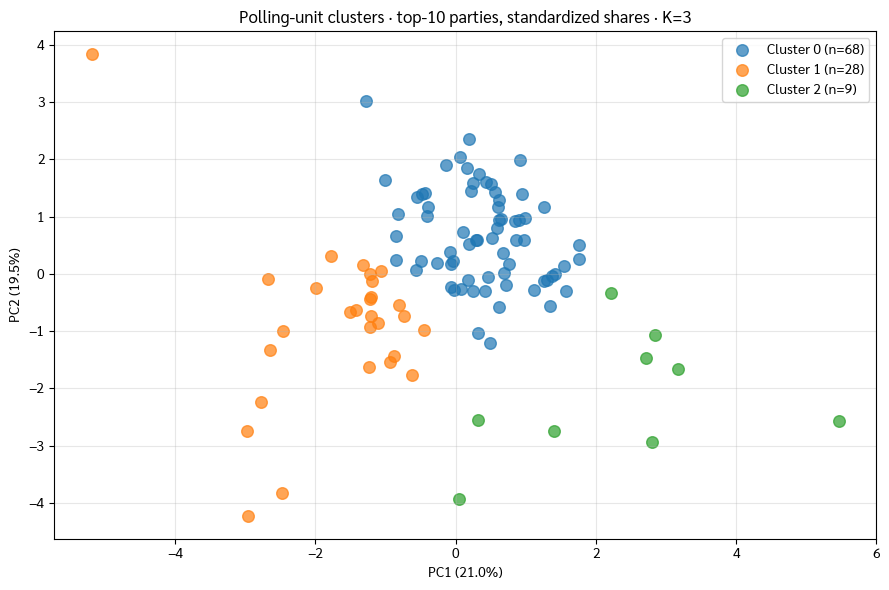


PC1 loadings (sorted):
party_name
เพื่อชาติไทย      -0.432
ไทยทรัพย์ทวี      -0.419
ประชาธิปัตย์      -0.389
ประชาชน           -0.218
รวมไทยสร้างชาติ   -0.172
กล้าธรรม          -0.109
ภูมิใจไทย         -0.094
เศรษฐกิจ           0.002
ประชาธิปไตยใหม่    0.105
เพื่อไทย           0.615

PC2 loadings (sorted):
party_name
ไทยทรัพย์ทวี      -0.379
กล้าธรรม          -0.338
ประชาธิปัตย์      -0.303
ประชาธิปไตยใหม่   -0.151
เพื่อไทย          -0.120
เพื่อชาติไทย       0.084
ภูมิใจไทย          0.294
ประชาชน            0.407
รวมไทยสร้างชาติ    0.419
เศรษฐกิจ           0.424

Cluster profiles (mean share, top-10):
party_name  กล้าธรรม  ประชาชน  ประชาธิปัตย์  ประชาธิปไตยใหม่  ภูมิใจไทย  รวมไทยสร้างชาติ  เพื่อชาติไทย  เพื่อไทย  เศรษฐกิจ  ไทยทรัพย์ทวี
cluster                                                                                                                                 
0              0.028    0.406         0.043            0.031      0.099            0.015         0.027     0.284    

In [81]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

top10 = (df_final_report[df_final_report["type"] == "ปาร์ตี้ลิสต์"]
         .groupby("party_name")["votes"].sum().nlargest(10).index)

pivot = (df_final_report[(df_final_report["type"] == "ปาร์ตี้ลิสต์") &
                         (df_final_report["party_name"].isin(top10))]
         .pivot_table(index=["tambon", "unit"], columns="party_name",
                      values="votes", aggfunc="sum").fillna(0))
shares = pivot.div(pivot.sum(axis=1), axis=0).dropna()

X = StandardScaler().fit_transform(shares.values)
pca = PCA(n_components=2)
comp = pca.fit_transform(X)
print(f"PC1 = {pca.explained_variance_ratio_[0]:.1%}, PC2 = {pca.explained_variance_ratio_[1]:.1%}, "
      f"total = {pca.explained_variance_ratio_[:2].sum():.1%}")

scores = [(k, silhouette_score(comp, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(comp)))
          for k in range(2, 6)]
print("Silhouette by K:", [(k, round(s, 3)) for k, s in scores])
best_k = max(scores, key=lambda x: x[1])[0]
clusters = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(comp)
print(f"Selected K = {best_k}")

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(best_k):
    m = clusters == c
    ax.scatter(comp[m, 0], comp[m, 1], s=70, alpha=0.7, label=f"Cluster {c} (n={m.sum()})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"Polling-unit clusters · top-10 parties, standardized shares · K={best_k}")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

loadings = pd.DataFrame(pca.components_.T, index=shares.columns, columns=["PC1", "PC2"])
print("\nPC1 loadings (sorted):")
print(loadings["PC1"].sort_values().round(3).to_string())
print("\nPC2 loadings (sorted):")
print(loadings["PC2"].sort_values().round(3).to_string())

profile = shares.assign(cluster=clusters).groupby("cluster").mean().round(3)
print("\nCluster profiles (mean share, top-10):")
print(profile.to_string())

### 4.3 Cluster Geography

Tying clusters back to the map. Coordinates sourced hierarchically:
1. **2566 polling-station data** — mean lat/lng over all stations in each ตำบล (most empirically reliable when present)
2. **Wikipedia/Wikidata** authoritative centroids — for ตำบล missing from the CSV
3. Source provenance tagged on every record for traceability.

Tested OpenStreetMap Nominatim API as a third option; rejected after it returned the district centroid for ตำบลแม่นะ (a known false-match issue with short Thai admin names).

In [96]:
import folium
import pandas as pd

# ===== Step 1: Build geo (hybrid: 2566 CSV preferred, Wikipedia fallback) =====
import requests
import time
import re
import pandas as pd

def get_tambons_from_wikidata(amphoe, province):
    s = requests.get("https://www.wikidata.org/w/api.php", params={
        "action": "wbsearchentities", "search": f"อำเภอ{amphoe}",
        "language": "th", "type": "item", "format": "json",
    }, headers={"User-Agent": "thai-election/1.0"}, timeout=10).json()
    amphoe_qid = next((it["id"] for it in s.get("search", [])
                       if it.get("label") in (f"อำเภอ{amphoe}", amphoe)), None)
    if amphoe_qid is None:
        print(f"   Wikidata: no QID for อำเภอ{amphoe}")
        return {}

    sparql = f"""
    SELECT ?tambon ?tambonLabel ?coord WHERE {{
      ?tambon wdt:P31 wd:Q726888.
      ?tambon wdt:P131 wd:{amphoe_qid}.
      ?tambon wdt:P625 ?coord.
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "th,en". }}
    }}
    """
    r = requests.get("https://query.wikidata.org/sparql",
                     params={"query": sparql, "format": "json"},
                     headers={"User-Agent": "thai-election/1.0",
                              "Accept": "application/sparql-results+json"},
                     timeout=20).json()
    coords = {}
    for b in r["results"]["bindings"]:
        label = b["tambonLabel"]["value"].replace("ตำบล", "").strip()
        m = re.match(r"Point\(([-\d.]+)\s+([-\d.]+)\)", b["coord"]["value"])
        if m:
            coords[label] = (float(m.group(2)), float(m.group(1)))
    print(f"  Wikidata: resolved {len(coords)} ตำบล for อำเภอ{amphoe}")
    return coords

# Tier 1 — 2566 CSV (mean over polling stations)
csv_geo = (df_final_cm6[df_final_cm6["district"] == AMPHOE]
           .groupby("subdistrict")[["lat_changable", "lng_changable"]]
           .mean(numeric_only=True).dropna().reset_index()
           .rename(columns={"subdistrict": "tambon_clean",
                            "lat_changable": "lat", "lng_changable": "lng"}))
csv_geo["tambon_clean"] = csv_geo["tambon_clean"].str.strip()
csv_geo["source"] = "2566_csv"

# Tier 2 — Wikidata SPARQL (auto for any อำเภอ)
wikidata_coords = get_tambons_from_wikidata(AMPHOE, PROVINCE)
wikidata_geo = pd.DataFrame([
    {"tambon_clean": t, "lat": lat, "lng": lng, "source": "wikidata"}
    for t, (lat, lng) in wikidata_coords.items()
])

# Tier 3 — manual overrides (only used when both above miss)
manual = WIKIPEDIA_COORDS_BY_AMPHOE.get(AMPHOE, {})
manual_geo = pd.DataFrame([
    {"tambon_clean": t, "lat": lat, "lng": lng, "source": "wiki"}
    for t, (lat, lng) in manual.items()
])

geo = (pd.concat([csv_geo, wikidata_geo, manual_geo], ignore_index=True)
       .drop_duplicates("tambon_clean", keep="first")
       .reset_index(drop=True))

print(f"\nFinal coverage: {len(geo)} ตำบล")
print(geo.to_string(index=False))
print(f"Source breakdown: {geo['source'].value_counts().to_dict()}")

# ===== Step 2: Build cluster_mix from current `shares` and `clusters` =====
df_unit_cluster = pd.DataFrame({
    "tambon":  shares.index.get_level_values("tambon"),
    "unit":    shares.index.get_level_values("unit"),
    "cluster": clusters,
})
df_unit_cluster["tambon_clean"] = (df_unit_cluster["tambon"]
    .str.replace("ตำบล", "", regex=False)
    .str.replace("ทต.",  "", regex=False).str.strip())

print(f"\n[2] df_unit_cluster: {len(df_unit_cluster)} units, "
      f"{df_unit_cluster['tambon_clean'].nunique()} unique ตำบล")
print(f"    Unique tambon_clean: {sorted(df_unit_cluster['tambon_clean'].unique())}")

cluster_cols = sorted(df_unit_cluster["cluster"].unique())
cluster_mix = (df_unit_cluster.groupby(["tambon_clean", "cluster"])
               .size().unstack(fill_value=0))
cluster_mix["total"]    = cluster_mix.sum(axis=1)
cluster_mix["dominant"] = cluster_mix[cluster_cols].idxmax(axis=1)
cluster_mix = cluster_mix.reset_index()
print(f"\n[3] cluster_mix: {len(cluster_mix)} ตำบล")

# ===== Step 3: Merge with indicator to catch any drops =====
df_map = cluster_mix.merge(geo, on="tambon_clean", how="left", indicator=True)
print(f"\n[4] After left-merge: {len(df_map)} rows")
print(df_map[["tambon_clean", "total", "dominant", "lat", "lng", "_merge"]].to_string(index=False))

missing = df_map[df_map["lat"].isna()]["tambon_clean"].tolist()
if missing:
    print(f"\n NO coords for: {missing}")
    print("   These ตำบล will not appear on the map.")

df_map = df_map.dropna(subset=["lat", "lng"]).drop(columns="_merge")
print(f"\n[5] Final mappable: {len(df_map)} ตำบล")

# ===== Step 4: Render =====
def label_cluster(row):
    top = row.idxmax()
    if top == "เพื่อไทย":
        return "เพื่อไทย stronghold"
    if top == "ประชาชน":
        return "ประชาชน-led modern" if row.get("เพื่อไทย", 0) > 0.20 else "Fragmented opposition"
    return f"{top}-led"

name_to_color = {
    "ประชาชน-led modern":     "orange",
    "Fragmented opposition":  "purple",
    "เพื่อไทย stronghold":    "red",
}
cluster_names  = {c: label_cluster(profile.loc[c]) for c in profile.index}
cluster_colors = {c: name_to_color.get(cluster_names[c], "gray") for c in cluster_names}

m = folium.Map(location=[df_map["lat"].mean(), df_map["lng"].mean()],
               zoom_start=10, tiles="CartoDB positron")

for _, r in df_map.iterrows():
    dom = int(r["dominant"])
    mix = " · ".join([f"C{c}={int(r[c])}" for c in cluster_cols if r[c] > 0])
    popup = (f"<b>ตำบล {r['tambon_clean']}</b><br>"
             f"Units: {int(r['total'])}<br>"
             f"Mix: {mix}<br>"
             f"Dominant: <b>{cluster_names[dom]}</b>")
    folium.CircleMarker(
        location=[r["lat"], r["lng"]],
        radius=6 + r["total"] * 0.6,
        color=cluster_colors[dom], fill=True,
        fill_color=cluster_colors[dom], fill_opacity=0.75,
        popup=folium.Popup(popup, max_width=320),
    ).add_to(m)

legend = """
<div style="position: fixed; bottom: 30px; left: 30px; width: 230px;
            background: white; border:2px solid #555; padding: 10px;
            font-size: 13px; z-index:9999; font-family: Garuda, sans-serif;">
<b>Dominant cluster per ตำบล</b><br>
<span style="background:orange;display:inline-block;width:14px;height:14px;border-radius:50%;"></span>
 ประชาชน-led modern<br>
<span style="background:purple;display:inline-block;width:14px;height:14px;border-radius:50%;"></span>
 Fragmented opposition<br>
<span style="background:red;display:inline-block;width:14px;height:14px;border-radius:50%;"></span>
 เพื่อไทย stronghold<br>
<small>Circle size ∝ units in ตำบล</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend))
m

  ⚠️ Wikidata: no QID for อำเภอเชียงดาว

Final coverage: 8 ตำบล
 tambon_clean       lat       lng   source
     เชียงดาว 19.377579 98.965117 2566_csv
     เมืองคอง 19.395688 98.718068 2566_csv
        แม่นะ 19.415717 98.940156 2566_csv
      เมืองนะ 19.593200 98.961800     wiki
     เมืองงาย 19.444800 98.966200     wiki
  ทุ่งข้าวพวง 19.534200 98.962100     wiki
      ปิงโค้ง 19.459200 98.994300     wiki
พระธาตุปู่ก่ำ 19.450000 98.990000     wiki
Source breakdown: {'wiki': 5, '2566_csv': 3}

[2] df_unit_cluster: 105 units, 8 unique ตำบล
    Unique tambon_clean: ['ทุ่งข้าวพวง', 'ปิงโค้ง', 'พระธาตุปู่ก่ำ', 'เชียงดาว', 'เมืองคอง', 'เมืองงาย', 'เมืองนะ', 'แม่นะ']

[3] cluster_mix: 8 ตำบล

[4] After left-merge: 8 rows
 tambon_clean  total dominant       lat       lng _merge
  ทุ่งข้าวพวง      8        0 19.534200 98.962100   both
      ปิงโค้ง     20        0 19.459200 98.994300   both
พระธาตุปู่ก่ำ      5        1 19.450000 98.990000   both
     เชียงดาว     23        0 19.377579 98.965117

### 4.4 Anomaly Detection

Per-unit feature vector: spoil_rate, no_vote_rate, ENP, top-share, margin (party-list and constituency). Standardized, then Isolation Forest with 8% contamination. Output is a flag and an anomaly score per unit; top anomalies are inspected manually for narrative.

In [84]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

sum_p = df_all_summary[df_all_summary["type"] == "ปาร์ตี้ลิสต์"].copy()
for c in ["ballots_used", "ballots_valid", "ballots_spoiled", "ballots_no_vote"]:
    sum_p[c] = pd.to_numeric(sum_p[c], errors="coerce")
sum_p["spoil_rate"]   = sum_p["ballots_spoiled"] / sum_p["ballots_used"]
sum_p["no_vote_rate"] = sum_p["ballots_no_vote"] / sum_p["ballots_used"]
sum_p["valid_rate"]   = sum_p["ballots_valid"]   / sum_p["ballots_used"]

df_features = sum_p[["tambon", "unit", "ballots_used",
                     "spoil_rate", "no_vote_rate", "valid_rate"]].merge(
    df_conc, on=["tambon", "unit"], how="left")

feature_cols = ["spoil_rate", "no_vote_rate", "ENP_plist", "ENP_khet",
                "top_share_plist", "margin_plist"]
df_features = df_features.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Modeling {len(df_features)} units across {df_features['tambon'].nunique()} ตำบล")

X = StandardScaler().fit_transform(df_features[feature_cols])
iso = IsolationForest(contamination=0.08, random_state=42).fit(X)
df_features["anomaly_score"] = -iso.decision_function(X)
df_features["is_anomaly"]    = iso.predict(X) == -1

n_anom = df_features["is_anomaly"].sum()
print(f"\nDetected {n_anom} anomalous units ({n_anom/len(df_features):.1%})")

print("\n=== Top 8 most anomalous units ===")
show_cols = ["tambon", "unit", "ballots_used", "spoil_rate", "no_vote_rate",
             "ENP_plist", "top_share_plist", "margin_plist", "anomaly_score"]
top_anom = df_features.sort_values("anomaly_score", ascending=False).head(8)[show_cols]
for c in ["spoil_rate", "no_vote_rate", "top_share_plist", "margin_plist"]:
    top_anom[c] = (top_anom[c] * 100).round(2).astype(str) + "%"
top_anom["ENP_plist"] = top_anom["ENP_plist"].round(2)
top_anom["anomaly_score"] = top_anom["anomaly_score"].round(3)
print(top_anom.to_string(index=False))

Modeling 105 units across 9 ตำบล

Detected 9 anomalous units (8.6%)

=== Top 8 most anomalous units ===
          tambon     unit  ballots_used spoil_rate no_vote_rate  ENP_plist top_share_plist margin_plist  anomaly_score
     ตำบลปิงโค้ง หน่วย 19           249       0.4%         0.0%       1.15          93.15%       91.13%          0.222
    ตำบลเมืองคอง  หน่วย 6           122      5.74%        0.82%       1.99          70.18%       64.04%          0.098
     ตำบลเมืองนะ หน่วย 21           370     15.41%        0.27%       3.76          49.36%       39.74%          0.028
     ตำบลเมืองนะ  หน่วย 5           516      7.36%        1.36%       2.40          63.27%       52.02%          0.023
    ตำบลเชียงดาว หน่วย 11           171      15.2%         0.0%       4.45          44.14%       31.72%          0.017
     ตำบลปิงโค้ง หน่วย 10           440      5.68%        0.91%       7.72          19.95%        0.73%          0.015
       ตำบลแม่นะ หน่วย 15            50       2.0%         4.0%

In [85]:
!apt-get install -y fonts-thai-tlwg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


### 4.5 Split-Ticket Regressio

Target party (largest by party-list votes): ประชาชน
Sample size: 105 units
Split-gap distribution: mean=-6.0%, std=11.0%, range=[-49.6%, 49.4%]

=== OLS (split-gap as % of valid ballots) ===
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.1733      0.399     -2.944      0.004      -1.964      -0.382
spoil_rate          0.2200      0.422      0.521      0.603      -0.617       1.057
no_vote_rate       -0.6571      0.413     -1.593      0.114      -1.476       0.162
ENP_plist           0.0727      0.033      2.220      0.029       0.008       0.138
ENP_khet            0.0107      0.008      1.271      0.207      -0.006       0.027
top_share_plist     2.2800      0.705      3.234      0.002       0.881       3.679
margin_plist       -1.0887      0.304     -3.585      0.001      -1.691      -0.486
OLS R² = 0.186,  adj R² = 0.136

XGBoost 5-fold CV R²

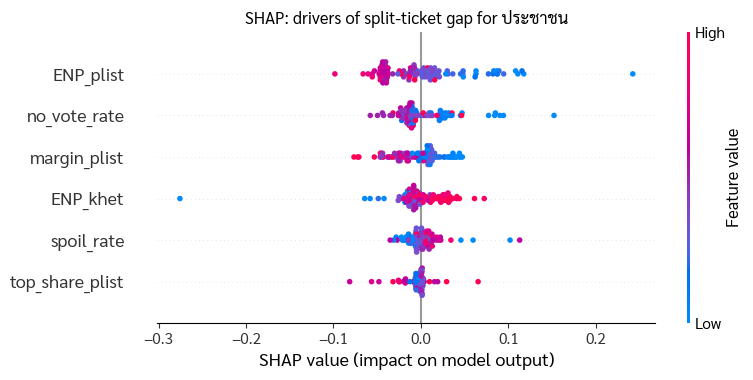

In [86]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
import matplotlib as mpl

!wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf

# 2. Add to Matplotlib font manager
mpl.font_manager.fontManager.addfont('Sarabun-Regular.ttf')

# 3. Set as default font
mpl.rc('font', family='Sarabun')

df_pv = (df_final_report
         .pivot_table(index=["tambon", "unit", "party_name"], columns="type",
                      values="votes", aggfunc="sum").fillna(0).reset_index())
df_pv.columns.name = None

unit_total_p = df_pv.groupby(["tambon", "unit"])["ปาร์ตี้ลิสต์"].transform("sum")
unit_total_k = df_pv.groupby(["tambon", "unit"])["เขต"].transform("sum")
df_pv["share_plist"]   = df_pv["ปาร์ตี้ลิสต์"] / unit_total_p
df_pv["share_khet"]    = df_pv["เขต"]         / unit_total_k
df_pv["split_gap_pct"] = df_pv["share_plist"] - df_pv["share_khet"]

target_party = df_pv.groupby("party_name")["ปาร์ตี้ลิสต์"].sum().idxmax()
print(f"Target party (largest by party-list votes): {target_party}")

df_t = (df_pv[df_pv["party_name"] == target_party]
        .merge(df_features[["tambon", "unit", "spoil_rate", "no_vote_rate",
                            "ENP_plist", "ENP_khet", "top_share_plist", "margin_plist"]],
               on=["tambon", "unit"], how="inner")
        .dropna(subset=["split_gap_pct"]).reset_index(drop=True))
print(f"Sample size: {len(df_t)} units")
print(f"Split-gap distribution: mean={df_t['split_gap_pct'].mean():.1%}, "
      f"std={df_t['split_gap_pct'].std():.1%}, "
      f"range=[{df_t['split_gap_pct'].min():.1%}, {df_t['split_gap_pct'].max():.1%}]")

X_cols = ["spoil_rate", "no_vote_rate", "ENP_plist", "ENP_khet",
          "top_share_plist", "margin_plist"]
X = df_t[X_cols].astype(float)
y = df_t["split_gap_pct"].astype(float)

print("\n=== OLS (split-gap as % of valid ballots) ===")
ols = sm.OLS(y, sm.add_constant(X)).fit()
print(ols.summary().tables[1])
print(f"OLS R² = {ols.rsquared:.3f},  adj R² = {ols.rsquared_adj:.3f}")

model = xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                         random_state=42)
cv = cross_val_score(model, X, y, cv=5, scoring="r2")
print(f"\nXGBoost 5-fold CV R²: mean = {cv.mean():.3f}, std = {cv.std():.3f}")
model.fit(X, y)

explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X)
shap.summary_plot(shap_vals, X, plot_type="dot", show=False)
plt.title(f"SHAP: drivers of split-ticket gap for {target_party}")
plt.tight_layout()
plt.show()